# 📊 Evaluación — HybridCNN Audio Classifier

Carga el modelo entrenado usando **el mismo pipeline que `inference_test.ipynb`** (autodetección de modo, sin hardcodear `mel_only` / `mel_mfcc`) y evalúa sobre el split `test` del dataset procesado.

Produce:
- Accuracy, F1 macro y reporte por clase
- Matriz de confusión con valores absolutos y normalizada
- Guardado automático de ambas figuras en `FINAL_MODEL_DIR`

## 1 · Importaciones

In [1]:
from __future__ import annotations

import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

from src.utils.config import (
    PROCESSED_METADATA,
    LABEL_MAPPING,
    FINAL_MODEL_DIR,
    CHECKPOINT_DIR,
)
from src.models.hybrid_cnn_v2 import ImprovedMFCCCNN
from src.models.audio_dataset import ProcessedAudioDataset, crnn_collate_fn

print("✅ Importaciones completadas")

✅ Importaciones completadas


## 2 · Configuración

In [2]:
# ─────────────────────────────────────────────
# 🔧 RUTAS — igual que inference_test.ipynb
# ─────────────────────────────────────────────
MODEL_PATH = FINAL_MODEL_DIR / "best_mfcc_cnn.pt"
# MODEL_PATH = CHECKPOINT_DIR / "checkpoint_epoch_16.pt"   # ← descomenta si usas checkpoint

LABEL_MAPPING_PATH = LABEL_MAPPING["human_label"]
TARGET_TYPE        = "human_label"

# ─────────────────────────────────────────────
# 🖥️ DATALOADER
# ─────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 4
DROPOUT     = 0.25

# ─────────────────────────────────────────────
# 📊 VISUALIZACIÓN
# ─────────────────────────────────────────────
FIG_SIZE       = (16, 13)   # tamaño de la figura de la matriz
ANNOT_ABSOLUTE = True       # mostrar números en la matriz absoluta
ANNOT_NORM     = True       # mostrar porcentajes en la normalizada

print(f"📦 Modelo       : {MODEL_PATH}")
print(f"🗂️  Label mapping : {LABEL_MAPPING_PATH}")
print(f"📋 Metadata CSV : {PROCESSED_METADATA}")

📦 Modelo       : /home/andres/Documentos/proyecto4geeks/models/final/best_mfcc_cnn.pt
🗂️  Label mapping : /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_human_label.pkl
📋 Metadata CSV : /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/processed_metadata.csv


## 3 · Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device_name = (
    torch.cuda.get_device_name(0)
    if device.type == "cuda"
    else "CPU"
)
print(f"🖥️  Dispositivo: {device} — {device_name}")

🖥️  Dispositivo: cuda — AMD Radeon RX 7600 XT


## 4 · Dataset y DataLoader de test

In [7]:
# ── Train dataset solo para heredar target_frames ────────────────────────────
# ProcessedAudioDataset infiere target_frames del primer .npy disponible.
# Usamos el split train como referencia para garantizar consistencia,
# igual que en 04_evaluation.ipynb original.
train_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="train",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_scalars=False,
)

# ── Test dataset ──────────────────────────────────────────────────────────────
test_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="test",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_scalars=False,
    target_frames=train_ds.target_frames,   # 🔥 CLAVE: mismos frames que train
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=crnn_collate_fn,
)

# Nombres de clases ordenados por índice
# label_mapping es {label: idx}, necesitamos {idx: label}
class_names = [k for k, v in sorted(test_ds.label_mapping.items(), key=lambda x: x[1])]
NUM_CLASSES = len(class_names)

print(f"✅ Test set      : {len(test_ds):,} muestras")
print(f"   Clases ({NUM_CLASSES})  : {class_names}")
print(f"   Target frames : {test_ds.target_frames}")

✅ Test set      : 21,847 muestras
   Clases (23)  : ['alert_sirem', 'ambient_noise', 'another_animal', 'breathing', 'car_crash', 'construction_noise', 'crime', 'crying', 'dog', 'domestic_activity', 'doors', 'engine', 'explosion', 'fight', 'fire', 'glass_metal', 'gun_shot', 'instrument', 'machine', 'traffic', 'voice', 'water', 'weather']
   Target frames : 360


## 5 · Cargar modelo (autodetección de modo — igual que `inference_test.ipynb`)

In [8]:
def detect_mode_from_state_dict(state_dict: dict) -> str:
    """Detecta mel_only / mfcc_only / mel_mfcc mirando las keys del state_dict."""
    keys = set(state_dict.keys())
    has_mel  = any(k.startswith("cnn_mel.")  for k in keys)
    has_mfcc = any(k.startswith("cnn_mfcc.") for k in keys)

    if has_mel and has_mfcc:
        return "mel_mfcc"
    elif has_mel:
        return "mel_only"
    elif has_mfcc:
        return "mfcc_only"
    else:
        raise ValueError("No se encontraron keys cnn_mel.* ni cnn_mfcc.* en el state_dict.")


def load_model(model_path, num_classes: int, dropout: float) -> tuple[ImprovedMFCCCNN, str]:
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
        print(f"   📌 Checkpoint — epoch: {checkpoint.get('epoch', '?')}  "
              f"| best_acc: {checkpoint.get('best_acc', '?')}")
    else:
        state_dict = checkpoint

    mode = detect_mode_from_state_dict(state_dict)
    print(f"   🔍 Modo detectado automáticamente: {mode}")

    model = ImprovedMFCCCNN(num_classes=num_classes, dropout=dropout, mode=mode).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, mode


model, MODE = load_model(MODEL_PATH, NUM_CLASSES, DROPOUT)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo cargado  |  {total_params:,} parámetros  |  modo: {MODE}")

   🔍 Modo detectado automáticamente: mel_only
✅ Modelo cargado  |  1,180,375 parámetros  |  modo: mel_only


## 6 · Inferencia sobre el split test

In [9]:
def prepare_inputs(batch: dict, device, mode: str):
    """Prepara los tensores de entrada según el modo del modelo."""
    mel  = batch.get("mel",  None)
    mfcc = batch.get("mfcc", None)

    if mel  is not None: mel  = mel.to(device)
    if mfcc is not None: mfcc = mfcc.to(device)

    if mode == "mel_only":
        return (mel,)
    elif mode == "mfcc_only":
        return (mel, mfcc)   # mel ignorado internamente
    else:  # mel_mfcc
        return (mel, mfcc)


@torch.no_grad()
def run_inference(model, loader, device, mode) -> tuple[list, list]:
    model.eval()
    y_true, y_pred = [], []

    for batch, labels, _ in tqdm(loader, desc="Evaluando"):
        labels = labels.to(device)
        inputs = prepare_inputs(batch, device, mode)
        logits = model(*inputs)
        preds  = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred


y_true, y_pred = run_inference(model, test_loader, device, MODE)

acc    = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average="macro",  zero_division=0)
f1_wt  = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n📊 Accuracy     : {acc:.4f}  ({acc:.2%})")
print(f"   F1 macro     : {f1_mac:.4f}")
print(f"   F1 weighted  : {f1_wt:.4f}")

Evaluando: 100%|██████████| 683/683 [00:39<00:00, 17.40it/s]



📊 Accuracy     : 0.6588  (65.88%)
   F1 macro     : 0.6383
   F1 weighted  : 0.6653


## 7 · Reporte por clase

In [10]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0,
    digits=3,
)
print(report)

                    precision    recall  f1-score   support

       alert_sirem      0.567     0.727     0.637      1346
     ambient_noise      0.533     0.654     0.587      1464
    another_animal      0.616     0.585     0.600       874
         breathing      0.502     0.491     0.496       646
         car_crash      0.861     0.849     0.855       465
construction_noise      0.733     0.745     0.739       605
             crime      0.994     0.998     0.996       512
            crying      0.832     0.806     0.819      1037
               dog      0.780     0.735     0.757       665
 domestic_activity      0.548     0.528     0.537      2369
             doors      0.460     0.607     0.523       267
            engine      0.684     0.738     0.710       473
         explosion      0.248     0.756     0.374        45
             fight      0.805     0.753     0.778       741
              fire      0.110     0.384     0.171       125
       glass_metal      0.767     0.651

## 8 · Matriz de confusión — valores absolutos

✅ Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_absolute.png


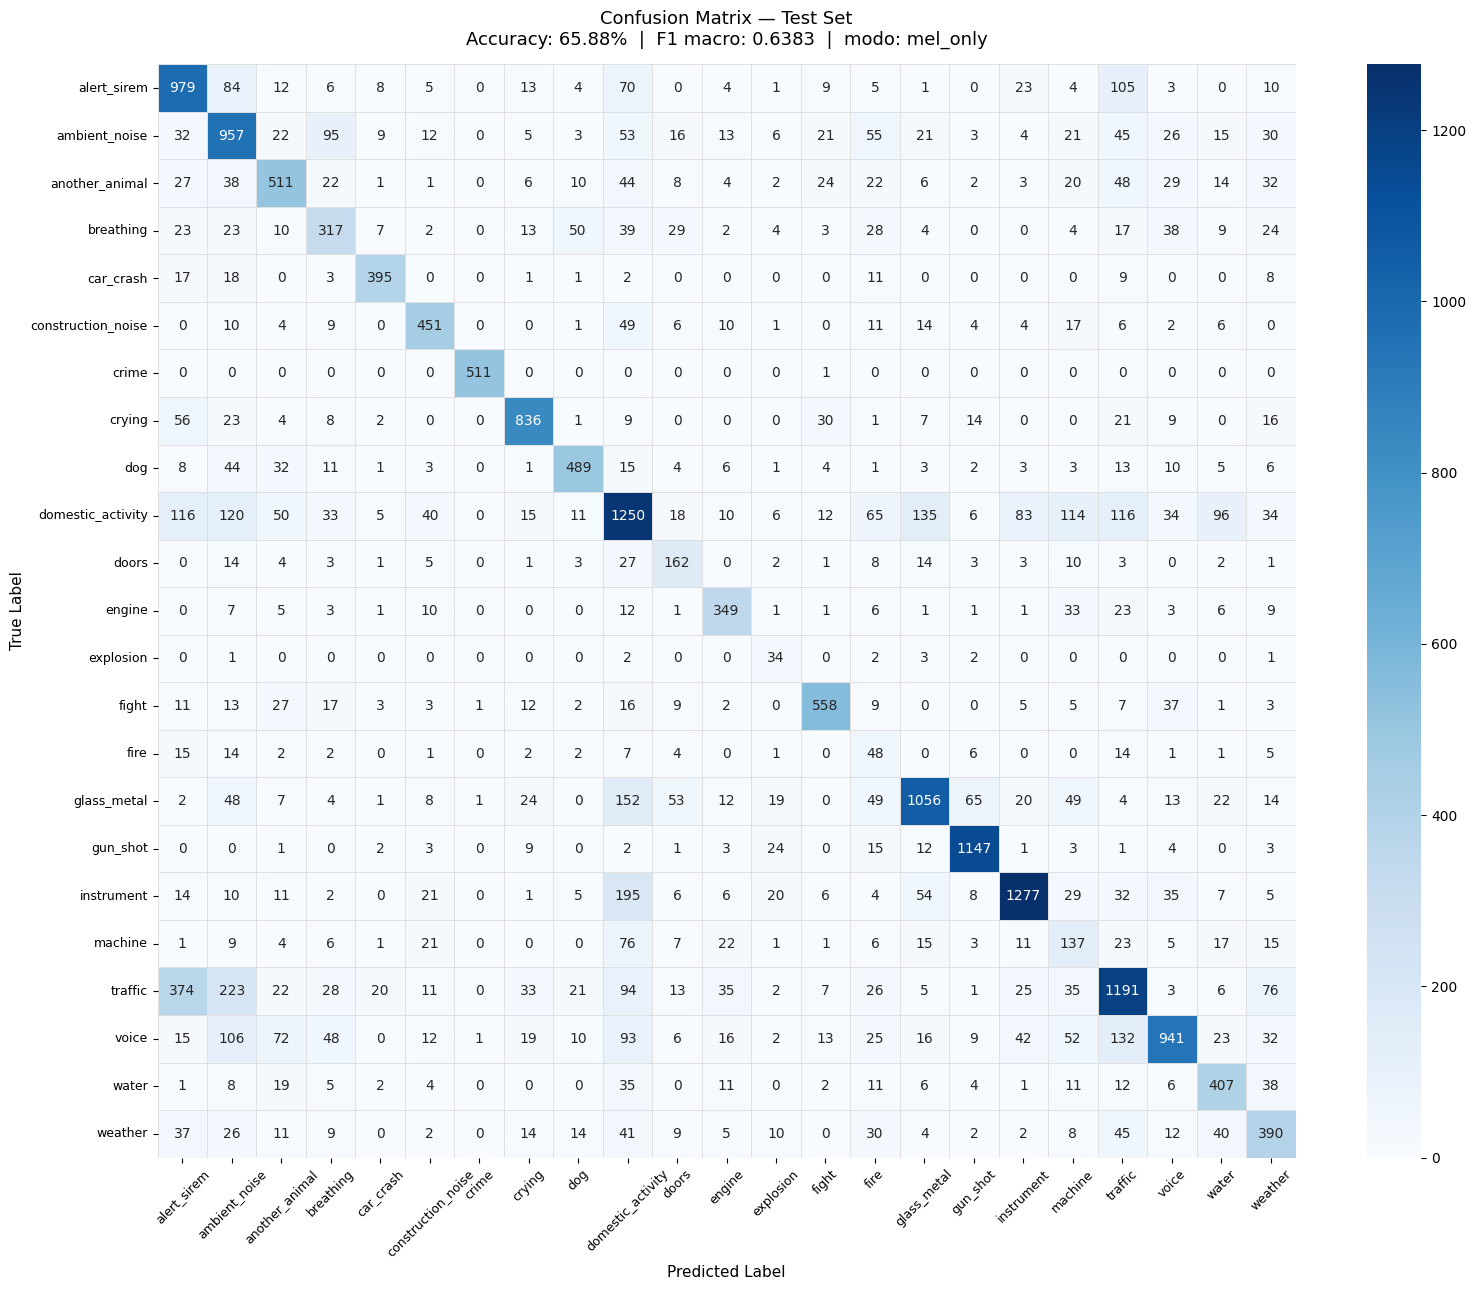

In [11]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    cm,
    annot=ANNOT_ABSOLUTE,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="#e0e0e0",
    ax=ax,
)

ax.set_title(
    f"Confusion Matrix — Test Set\nAccuracy: {acc:.2%}  |  F1 macro: {f1_mac:.4f}  |  modo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()

save_path = FINAL_MODEL_DIR / "confusion_matrix_absolute.png"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
fig.savefig(save_path, dpi=180, bbox_inches="tight")
print(f"✅ Guardada en: {save_path}")

plt.show()

## 9 · Matriz de confusión — normalizada por fila (recall por clase)

✅ Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_normalized.png


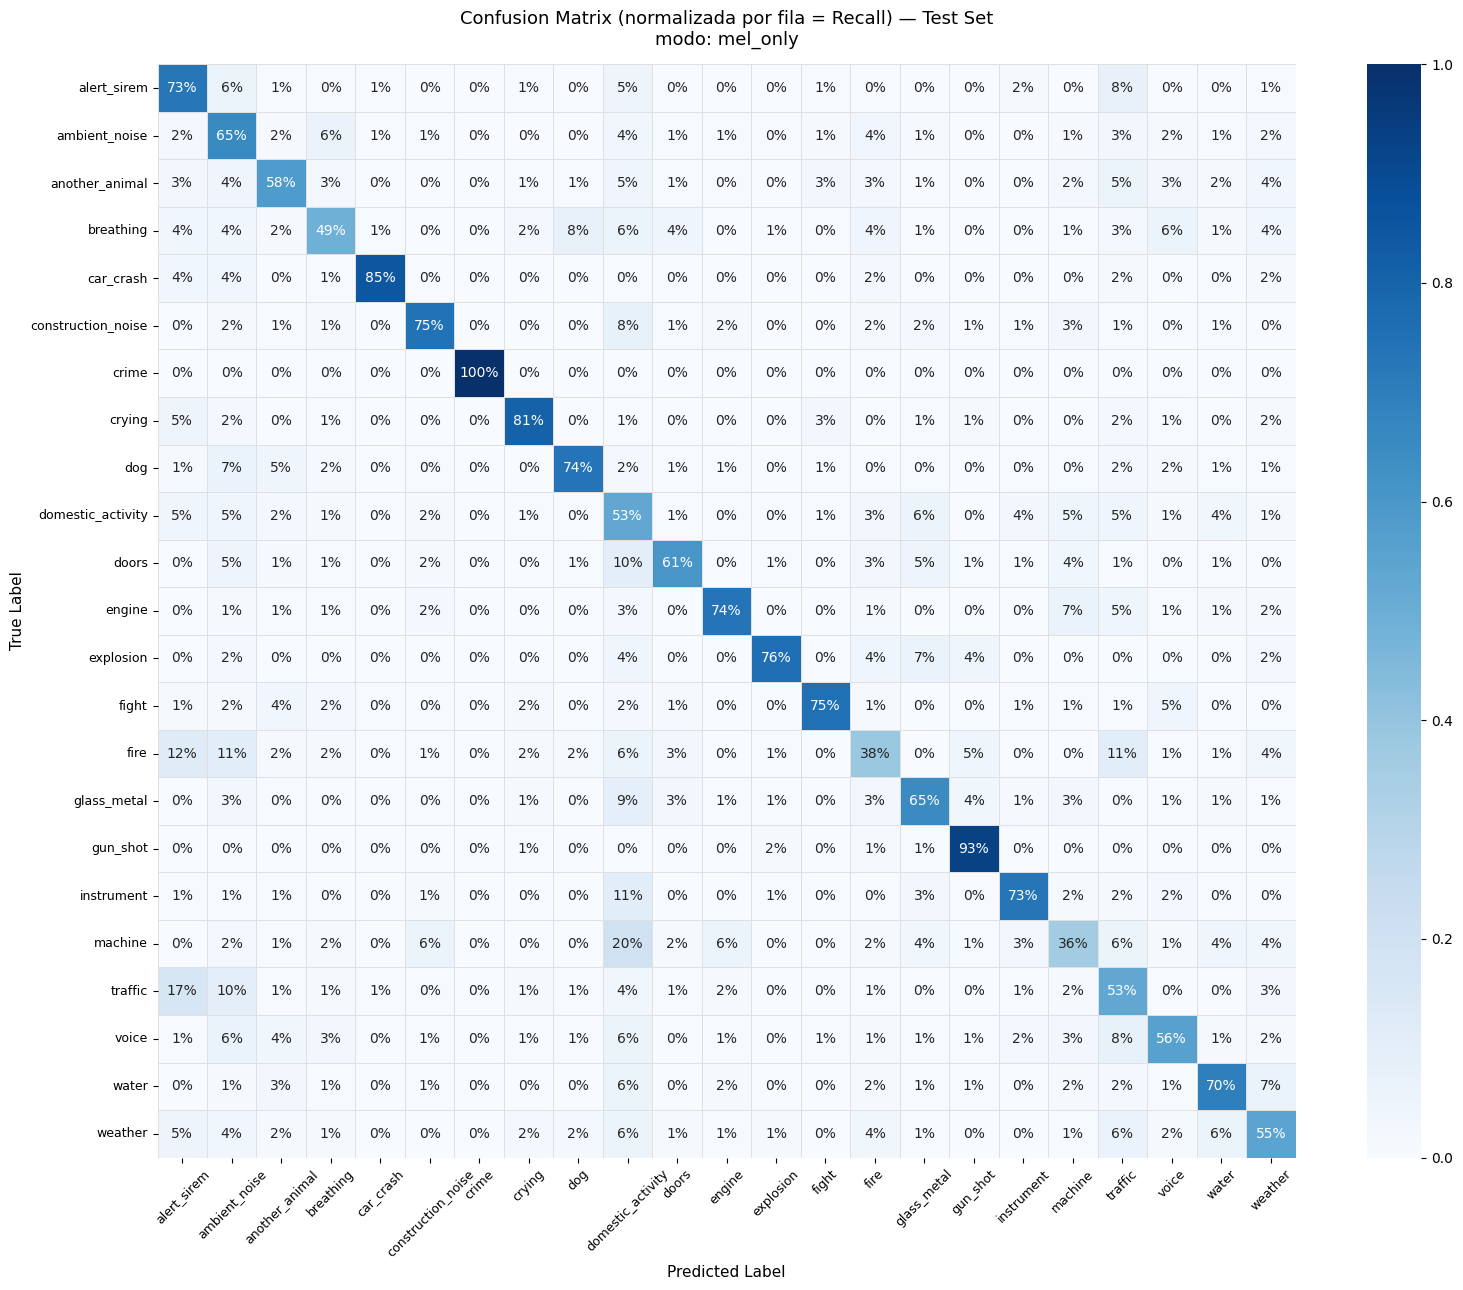

In [12]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=FIG_SIZE)

annot_data = (
    np.array([[f"{v:.0%}" for v in row] for row in cm_norm])
    if ANNOT_NORM else False
)

sns.heatmap(
    cm_norm,
    annot=annot_data if ANNOT_NORM else False,
    fmt="",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="#e0e0e0",
    ax=ax,
)

ax.set_title(
    f"Confusion Matrix (normalizada por fila = Recall) — Test Set\nmodo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()

save_path_norm = FINAL_MODEL_DIR / "confusion_matrix_normalized.png"
fig.savefig(save_path_norm, dpi=180, bbox_inches="tight")
print(f"✅ Guardada en: {save_path_norm}")

plt.show()

## 10 · Clases con más errores

📉 Clases ordenadas por recall (peor → mejor):


,Clase,Recall,Muestras test
0,machine,35.96%,381
1,fire,38.40%,125
2,breathing,49.07%,646
3,domestic_activity,52.76%,2369
4,traffic,52.91%,2251
5,weather,54.85%,711
6,voice,55.85%,1685
7,another_animal,58.47%,874
8,doors,60.67%,267
9,glass_metal,65.06%,1623



✅ Guardado en: /home/andres/Documentos/proyecto4geeks/models/final/recall_per_class.png


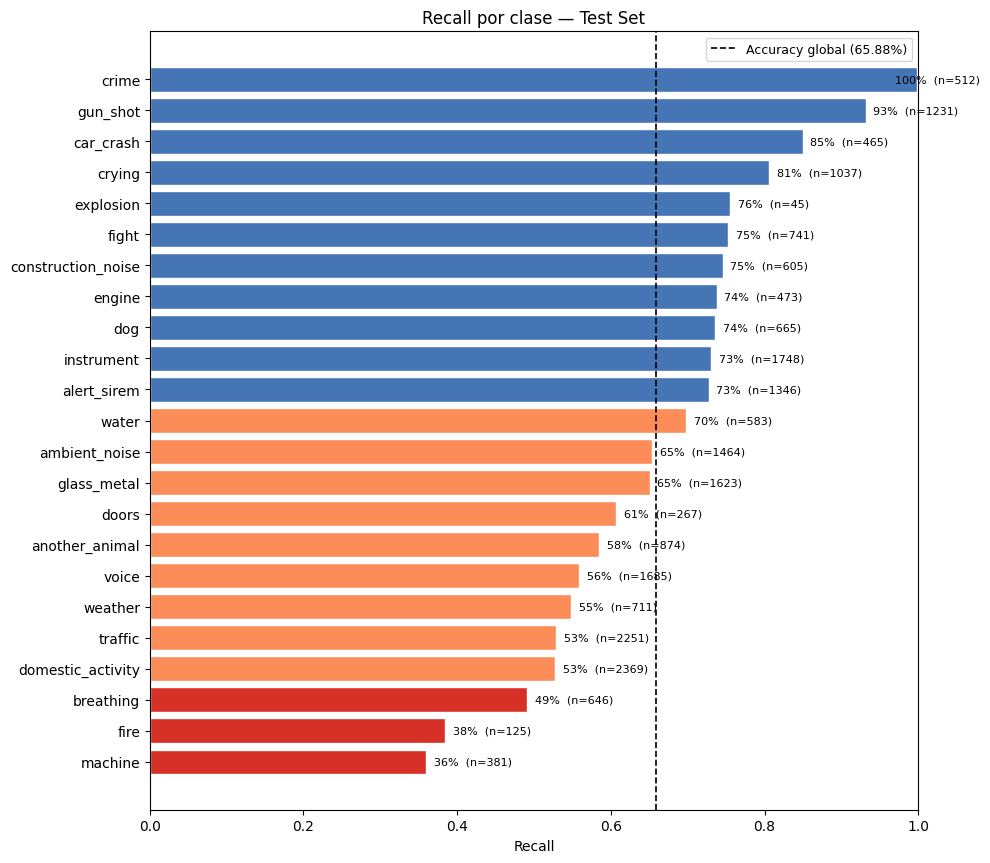

In [13]:
import pandas as pd

# Recall por clase (diagonal / total real de esa clase)
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Cuántas muestras reales tiene cada clase
support = cm.sum(axis=1)

df_perf = (
    pd.DataFrame({
        "class":   class_names,
        "recall":  per_class_recall,
        "support": support,
    })
    .sort_values("recall")
    .reset_index(drop=True)
)

df_perf["recall_fmt"] = df_perf["recall"].map("{:.2%}".format)

print("📉 Clases ordenadas por recall (peor → mejor):")
display(df_perf[["class", "recall_fmt", "support"]].rename(
    columns={"class": "Clase", "recall_fmt": "Recall", "support": "Muestras test"}
))

# ── Barplot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, NUM_CLASSES * 0.38)))

colors = ["#d73027" if r < 0.5 else "#fc8d59" if r < 0.7 else "#4575b4"
          for r in df_perf["recall"]]

ax.barh(df_perf["class"], df_perf["recall"], color=colors, edgecolor="white")
ax.axvline(x=acc, color="black", linestyle="--", linewidth=1.2, label=f"Accuracy global ({acc:.2%})")
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_title("Recall por clase — Test Set")
ax.legend(fontsize=9)

for i, (r, sup) in enumerate(zip(df_perf["recall"], df_perf["support"])):
    ax.text(min(r + 0.01, 0.97), i, f"{r:.0%}  (n={sup})", va="center", fontsize=8)

plt.tight_layout()

save_path_bar = FINAL_MODEL_DIR / "recall_per_class.png"
fig.savefig(save_path_bar, dpi=150, bbox_inches="tight")
print(f"\n✅ Guardado en: {save_path_bar}")

plt.show()

## 11 · Confusiones más frecuentes (top errores)

In [14]:
# Extraer pares (real, predicho) con más confusiones (fuera de la diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = [
    {
        "true":      class_names[i],
        "predicted": class_names[j],
        "count":     cm_off[i, j],
        "recall_true": f"{per_class_recall[i]:.0%}",
    }
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm_off[i, j] > 0
]

df_errors = (
    pd.DataFrame(pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

print("⚠️  Top-20 confusiones (real → predicho):")
display(df_errors)

⚠️  Top-20 confusiones (real → predicho):


,true,predicted,count,recall_true
0,traffic,alert_sirem,374,53%
1,traffic,ambient_noise,223,53%
2,instrument,domestic_activity,195,73%
3,glass_metal,domestic_activity,152,65%
4,domestic_activity,glass_metal,135,53%
5,voice,traffic,132,56%
6,domestic_activity,ambient_noise,120,53%
7,domestic_activity,alert_sirem,116,53%
8,domestic_activity,traffic,116,53%
9,domestic_activity,machine,114,53%
